# Feature Engineering

**Applied ML in Production · Session 3**

---

Session 2 left us with an honest model: leak removed, gaps imputed, AUC 0.78.
This session asks the next question — *can we give the model better columns?*

Feature engineering is the work of turning what you know about the business into
columns a model can use. A credit officer does not look at "loan amount" and
"annual income" separately; they look at the **ratio**, because a 500,000 rupee
loan means one thing to a business earning 2 million and another to a business
earning 600,000. That ratio is not in the file. Someone has to put it there.

This is where domain knowledge beats algorithms on tabular data — and it is also
where teams waste weeks building columns that turn out to be worth nothing. So we
will do both halves of the job: build features, then **measure whether they
earned their place**.

We finish with the 13.5% class imbalance we have been ignoring since session 1.

## How to work through this

Type the code yourself. Every cell is short, and most of the work is one line of
arithmetic on two columns you already have.

Run each cell, read the output, then read the commentary. If a cell errors, run
from the top.

## Learning objectives

After this session you will be able to:

- Create features of the five kinds that matter on tabular data: ratios,
  interactions, flags, aggregations, and date parts.
- Explain why a linear model cannot see an interaction unless you build it.
- **Measure** whether a new feature earned its place, instead of assuming it did.
- Select features with filter, wrapper, and embedded methods, and defend a
  smaller model.
- Handle a high-cardinality categorical column, and decide whether to keep it.
- Handle class imbalance with class weights, resampling, or a shifted threshold —
  and say which one changes what.

## Setup

Same helper as before, plus one small function so we can score a feature set in
one line and compare fairly.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 120)


def find_data(filename="loan_default.csv"):
    for folder in [Path.cwd(), *Path.cwd().parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"could not find data/{filename}")


loans = pd.read_csv(find_data(), parse_dates=["application_date"])
y = loans["defaulted"]
print(f"{len(loans):,} applications, default rate {y.mean():.1%}")

12,000 applications, default rate 13.5%


In [2]:
def evaluate(features, label, threshold=0.5, balanced=True):
    """Encode, split, impute, scale, fit, score. Returns the fitted model."""
    X = pd.get_dummies(features, drop_first=True).astype(float)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=42
    )
    medians = X_train.median()
    X_train, X_test = X_train.fillna(medians), X_test.fillna(medians)

    scaler = StandardScaler().fit(X_train)
    model = LogisticRegression(
        max_iter=1000, class_weight="balanced" if balanced else None
    ).fit(scaler.transform(X_train), y_train)

    probabilities = model.predict_proba(scaler.transform(X_test))[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    print(f"{label:<32} {X.shape[1]:>2} cols   "
          f"AUC {roc_auc_score(y_test, probabilities):.3f}   "
          f"recall {recall_score(y_test, predictions):.3f}   "
          f"precision {precision_score(y_test, predictions, zero_division=0):.3f}")
    return model

---

## 1. Why a model needs help

A model can only combine the columns you give it. A **linear** model can only add
them up — so any relationship that is not a weighted sum is invisible to it
unless you build the column yourself.

Here is the smallest possible demonstration. Risk appears only when a loan is
**both** large **and** short-term. Two features, one obvious rule.

In [3]:
rng = np.random.default_rng(0)
size = rng.uniform(1, 10, 4000)        # loan size
term = rng.uniform(1, 10, 4000)        # loan term
risky = ((size > 6) & (term < 4)).astype(int)   # risky only when BOTH hold

toy = pd.DataFrame({"size": size, "term": term})

X_train, X_test, y_train, y_test = train_test_split(toy, risky, test_size=0.25, random_state=0)
plain = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_train, y_train)
print(f"raw columns only: precision {precision_score(y_test, plain.predict(X_test)):.3f}")

toy_plus = toy.assign(interaction=toy["size"] * (10 - toy["term"]))
X_train, X_test, y_train, y_test = train_test_split(toy_plus, risky, test_size=0.25, random_state=0)
better = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_train, y_train)
print(f"with interaction: precision {precision_score(y_test, better.predict(X_test)):.3f}")

raw columns only: precision 0.696
with interaction: precision 0.805


Same data, same algorithm, same rows. One extra column — "large loan combined
with short term" — and precision jumps from 0.70 to 0.81.

The model did not get smarter. We stopped asking it to express something it
cannot express.

That is the whole idea. The question for every project is which of these columns
your business actually has, and the answer comes from the person who does the job
by hand, not from the data.

---

## 2. The five kinds of feature you will build

| Kind | What it is | In this project |
|------|-----------|-----------------|
| **Ratio** | One quantity relative to another | `loan_amount / annual_income` — debt burden |
| **Interaction** | Two features combined | large loan **and** short tenure |
| **Flag** | A yes/no fact pulled out of a number | "has ever been past due", "first-time borrower" |
| **Aggregation** | A summary over a group | average default rate of the branch, loans per customer |
| **Date part** | Something extracted from a timestamp | month, quarter, days since last loan |

Two cautions before we build.

**Aggregations over the target leak.** "Average default rate of this branch"
computed over the whole dataset includes the row you are predicting. If you build
one, it must be computed inside the training fold only — session 7.

**Date parts teach the model *when*.** A feature like "applied in Q4" can work
beautifully until the next Q4 looks different. Use them deliberately, and read
session 8 before you ship one.

In [4]:
features = loans[["loan_amount", "tenure_months", "interest_rate", "previous_loans",
                  "days_past_due_history", "annual_income", "credit_score",
                  "sector", "employment_type", "has_collateral"]].copy()

# Flags from session 2 — missingness was informative.
features["income_missing"] = features["annual_income"].isna().astype(int)
features["score_missing"] = features["credit_score"].isna().astype(int)

baseline_model = evaluate(features, "session 2 features")

session 2 features               18 cols   AUC 0.782   recall 0.694   precision 0.275


In [5]:
engineered = features.copy()

income = engineered["annual_income"].fillna(engineered["annual_income"].median())

# Ratios — how a credit officer actually reads a file.
engineered["loan_to_income"] = engineered["loan_amount"] / income
engineered["monthly_instalment"] = engineered["loan_amount"] / engineered["tenure_months"]
engineered["instalment_to_income"] = engineered["monthly_instalment"] / (income / 12)

# Flags — a yes/no fact hidden inside a count.
engineered["has_past_due"] = (engineered["days_past_due_history"] > 0).astype(int)
engineered["first_time_borrower"] = (engineered["previous_loans"] == 0).astype(int)

# Interaction — a big loan over a short term.
engineered["size_over_term"] = engineered["loan_amount"] / engineered["tenure_months"] / 1000

engineered_model = evaluate(engineered, "+ engineered features")

+ engineered features            24 cols   AUC 0.782   recall 0.686   precision 0.271


Six sensible, domain-driven features. AUC moved from 0.782 to 0.782.

**Nothing.** And this is the most useful result in the session.

### Why nothing happened, and what to do about it

The honest explanation is that on this dataset the risk really is close to a
weighted sum of the raw columns, and logistic regression was already finding it.
Our ratio is genuine domain knowledge, but it is knowledge the model had already
reconstructed from `loan_amount` and `annual_income` on its own.

That will not always be true. On messier data — where relationships are
multiplicative, where thresholds matter, where the signal lives in an
aggregation — engineered features routinely move a model further than any
algorithm change. The only way to know which world you are in is to **measure**.

So what did the work buy us here?

- **Explainability.** "Instalment is 60% of monthly income" is a sentence a
  credit officer can act on. "The coefficient on `loan_amount` is 0.32" is not.
- **Fewer columns for the same score.** A ratio can replace the two columns it
  was built from — we test that in section 4.
- **Stability.** Ratios survive inflation and policy changes better than raw
  rupee amounts, which drift year over year.

> **Industry note — the feature that was worth a team.**
> Feature engineering is unevenly rewarding. On credit and fraud problems, the
> single feature "velocity — how many applications from this device in the last
> hour" has been worth more than every model change a team made that year. On
> other problems, weeks of feature work move nothing. Build in small batches,
> measure each batch, and stop when the measurements stop moving.

---

## 3. Transformations

A transformation changes the *shape* of a feature rather than creating a new
quantity.

**Log for skew.** Money is right-skewed; `np.log1p` makes it roughly symmetric,
which suits linear models. We saw this in session 2.

**Binning for interpretability.** Chopping a continuous feature into bands throws
away information — and is standard practice in credit scoring anyway, because
bands are what a policy document can contain and a regulator can read.

In [6]:
bands = pd.cut(loans["credit_score"],
               bins=[0, 500, 580, 660, 740, 850],
               labels=["very poor", "poor", "fair", "good", "excellent"])

summary = pd.DataFrame({
    "applications": bands.value_counts().sort_index(),
    "default_rate": loans.groupby(bands, observed=True)["defaulted"].mean().round(3),
})
print(summary.to_string())

              applications  default_rate
credit_score                            
very poor              806         0.360
poor                  2227         0.212
fair                  3585         0.138
good                  2938         0.067
excellent             1593         0.035


The default rate falls cleanly from one band to the next — 36% in the lowest
band, 3.5% in the highest, and no reversals in between. That monotonic pattern is exactly what a scorecard needs: a policy
you can write down, argue about in a committee, and explain to a declined
applicant.

Notice the trade-off. The bands are easier to defend and slightly less
informative than the raw score, because everyone inside a band now looks
identical to the model. Credit teams accept that trade every day. Ask which one
your project needs before you choose.

---

## 4. Feature selection

More features is not better. Each one costs you:

- **Noise.** A column with no signal can still fit itself to the training data.
- **Money and fragility.** Every feature is a field someone must supply at
  serving time, and a thing that can go missing at 3am.
- **Explainability.** A model with 8 features can be explained; one with 80
  cannot.

Three families of method:

| Family | Idea | Example |
|--------|------|---------|
| **Filter** | Score each feature against the target on its own | correlation, mutual information |
| **Wrapper** | Repeatedly train and drop the weakest | recursive feature elimination |
| **Embedded** | Let the model do it while fitting | L1 (lasso) penalty, tree importances |

Start with a filter to understand the data, then check with an embedded method.

In [7]:
from sklearn.feature_selection import mutual_info_classif

X = pd.get_dummies(features, drop_first=True).astype(float)
X = X.fillna(X.median())

scores = pd.Series(mutual_info_classif(X, y, random_state=0), index=X.columns)
print("mutual information with the target (filter method)")
print(scores.sort_values(ascending=False).head(8).round(4).to_string())

mutual information with the target (filter method)
interest_rate               0.0425
credit_score                0.0309
annual_income               0.0132
days_past_due_history       0.0086
loan_amount                 0.0070
has_collateral_Yes          0.0052
sector_Trade                0.0048
employment_type_Informal    0.0030


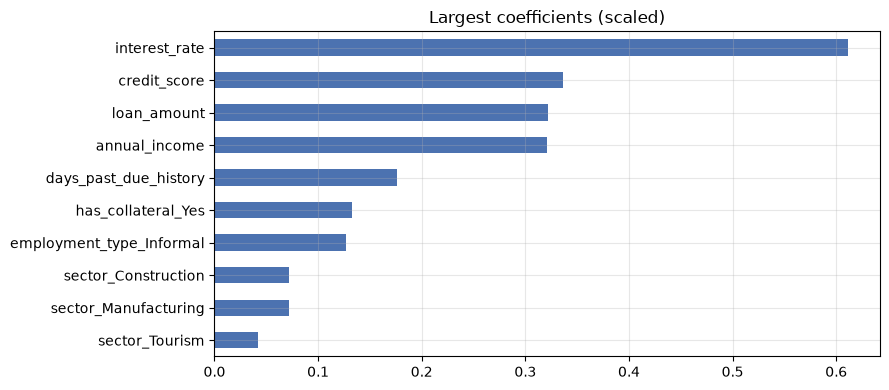

In [8]:
# Embedded view: coefficient size from the scaled model we already fitted.
importance = pd.Series(np.abs(baseline_model.coef_[0]), index=X.columns)
importance = importance.sort_values(ascending=False)

importance.head(10).iloc[::-1].plot.barh(color="#4C72B0", title="Largest coefficients (scaled)")
plt.tight_layout()
plt.show()

Both methods agree on the top of the list: `interest_rate` first, then
`credit_score`. That makes sense — the lender already prices risk into the rate,
so the rate is partly a summary of everything the credit officer knew.

Now the question that matters: **how few features can we keep?**

In [9]:
for n_features in [3, 4, 6, 8, 12, X.shape[1]]:
    keep = importance.head(n_features).index
    evaluate(X[keep], f"top {n_features} features")

top 3 features                    3 cols   AUC 0.754   recall 0.657   precision 0.256
top 4 features                    4 cols   AUC 0.769   recall 0.672   precision 0.259
top 6 features                    6 cols   AUC 0.779   recall 0.684   precision 0.265
top 8 features                    8 cols   AUC 0.783   recall 0.699   precision 0.272
top 12 features                  12 cols   AUC 0.782   recall 0.686   precision 0.271
top 18 features                  18 cols   AUC 0.782   recall 0.694   precision 0.275


Eight features score **as well as all eighteen** — in fact marginally better,
because the columns we dropped were contributing noise rather than signal.

That is a result worth taking to a stakeholder. The same performance, with less
than half the data to collect, validate, and monitor. In production, features are
a recurring cost; this is how you lower it.

The usual caution applies: importance is not causation. `interest_rate` is high
on the list because the lender's own pricing already encodes risk — it predicts
default without causing it. Dropping a feature because it scores low is safe;
telling the business "raise rates to reduce defaults" because it scores high
would be nonsense.

### The branch question

Session 2 left `branch` out with a promise to revisit. It has 40 values, which
one-hot encodes into 40 columns. Three options, one measurement.

In [10]:
with_all_branches = features.assign(branch=loans["branch"])

top_branches = loans["branch"].value_counts().head(10).index
grouped = loans["branch"].where(loans["branch"].isin(top_branches), "Other")
with_grouped_branches = features.assign(branch=grouped)

evaluate(features, "no branch")
evaluate(with_all_branches, "all 40 branches")
evaluate(with_grouped_branches, "top 10 branches + Other")

no branch                        18 cols   AUC 0.782   recall 0.694   precision 0.275
all 40 branches                  57 cols   AUC 0.778   recall 0.681   precision 0.269
top 10 branches + Other          28 cols   AUC 0.782   recall 0.689   precision 0.271


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

All 40 branches makes the model slightly **worse** — 40 columns of mostly empty
indicators, each offering a chance to memorise a handful of rows. Grouping
recovers the loss but buys nothing over leaving it out entirely.

Verdict: leave `branch` out. Which is the answer more often than students expect,
and it took three lines to establish rather than an afternoon of argument.

If branch genuinely mattered, the right move would not be 40 indicator columns.
It would be a feature that says *why* a branch differs — its size, its age, the
mix of sectors it lends to — because those are things a new branch also has.

---

## 5. Class imbalance

13.5% of these loans default. That imbalance has been quietly shaping every
result so far, and every one of our models has used `class_weight="balanced"`
without explanation. Time to explain it.

Start by seeing what happens with no handling at all.

In [11]:
evaluate(features, "no imbalance handling", balanced=False)
evaluate(features, "class_weight='balanced'", balanced=True)

no imbalance handling            18 cols   AUC 0.782   recall 0.091   precision 0.569


class_weight='balanced'          18 cols   AUC 0.782   recall 0.694   precision 0.275


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

Look at what changed and what did not.

**Recall collapsed to 0.09 without handling.** Untouched, the model learns that
predicting "repaid" is right 86.5% of the time and barely ever commits to a
default. Precision is high because it only flags the cases it is sure about, and
the model is useless — it misses 91% of the defaults it exists to find.

**AUC did not move at all: 0.782 in both rows.** That is the key fact of this
whole section. AUC measures how well the model *ranks* applications. Imbalance
handling does not improve the ranking; it moves the **threshold** at which we
decide to act.

### Three levers, one dial

In [12]:
from imblearn.over_sampling import SMOTE

X_encoded = pd.get_dummies(features, drop_first=True).astype(float)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, stratify=y, random_state=42
)
medians = X_train.median()
X_train, X_test = X_train.fillna(medians), X_test.fillna(medians)
scaler = StandardScaler().fit(X_train)
X_train_scaled, X_test_scaled = scaler.transform(X_train), scaler.transform(X_test)

# SMOTE invents synthetic minority rows — on the TRAINING data only, never the test set.
X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(X_train_scaled, y_train)
print(f"training defaults before SMOTE: {y_train.sum():,} of {len(y_train):,}")
print(f"training defaults after SMOTE:  {y_resampled.sum():,} of {len(y_resampled):,}")

smote_model = LogisticRegression(max_iter=1000).fit(X_resampled, y_resampled)
probabilities = smote_model.predict_proba(X_test_scaled)[:, 1]
predictions = (probabilities >= 0.5).astype(int)
print(f"\nSMOTE: AUC {roc_auc_score(y_test, probabilities):.3f}  "
      f"recall {recall_score(y_test, predictions):.3f}  "
      f"precision {precision_score(y_test, predictions):.3f}")

training defaults before SMOTE: 1,217 of 9,000
training defaults after SMOTE:  7,783 of 15,566

SMOTE: AUC 0.782  recall 0.686  precision 0.270


SMOTE gives AUC 0.782 — the same number again, with recall and precision landing
almost exactly where `class_weight="balanced"` put them.

| Lever | What it does | Cost |
|-------|--------------|------|
| **Class weights** | Tells the loss function a default matters more | One argument; nothing else changes |
| **Resampling** (SMOTE, oversampling, undersampling) | Rebalances the training rows | Bigger training set, synthetic rows, must sit inside cross-validation |
| **Threshold shifting** | Keeps the model, changes the cut-off for acting | Free, reversible, and the only one the business can tune after deployment |

All three arrive at the same place because none of them adds information. They
only decide *where on the ranking you draw the line*.

**Never resample the test set.** It must keep the real 13.5% rate, or your
measurements describe a world that does not exist. The same applies inside
cross-validation: resample each training fold, never the validation fold —
session 7 wires that correctly with a pipeline.

### Threshold shifting, which is the one you will actually use

Train once, with no reweighting, and sweep the cut-off.

In [13]:
plain_model = LogisticRegression(max_iter=1000).fit(X_train_scaled, y_train)
probabilities = plain_model.predict_proba(X_test_scaled)[:, 1]

rows = []
for threshold in [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
    predictions = (probabilities >= threshold).astype(int)
    rows.append({
        "threshold": threshold,
        "recall": recall_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "flagged": predictions.mean(),
    })

sweep = pd.DataFrame(rows).set_index("threshold").round(3)
print(sweep.to_string())

           recall  precision  flagged
threshold                            
0.05        0.968      0.174    0.752
0.10        0.817      0.237    0.465
0.15        0.644      0.284    0.307
0.20        0.511      0.333    0.207
0.30        0.328      0.442    0.100
0.50        0.091      0.569    0.022


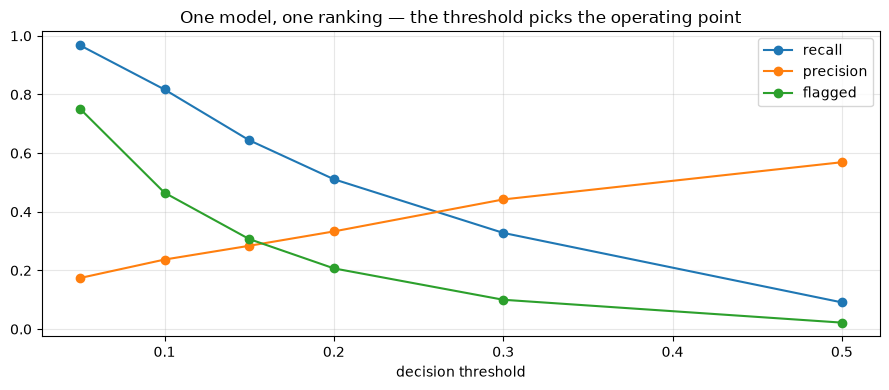

In [14]:
sweep[["recall", "precision", "flagged"]].plot(marker="o")
plt.xlabel("decision threshold")
plt.title("One model, one ranking — the threshold picks the operating point")
plt.tight_layout()
plt.show()

One trained model, six different systems. At 0.10 we catch 82% of defaults and
send 46% of applications to review. At 0.30 we catch a third and review a tenth.

Nothing about the model changed between those rows. **The threshold is a business
decision**, made by whoever owns the review capacity and the cost of a missed
default — not by a default argument in scikit-learn.

Session 1 wrote the criterion: catch at least 60% of defaults while flagging no
more than 25%. Read it off the table: at a threshold of 0.15 we reach 64% recall
at 31% flagged. Still short on the flagging constraint, and now we know exactly
what the gap is. Sessions 5 and 6 close it.

---

## 6. A working checklist

**Build, in this order**
1. Ratios the domain expert already computes in their head.
2. Flags for facts hidden inside numbers (zero, missing, first-time).
3. Interactions you have a reason to expect — not every pair.
4. Aggregations, carefully, and only inside the training fold.
5. Date parts, deliberately, knowing they encode *when*.

**Then check, every time**
- Does the score move? If not, keep the simpler feature set.
- Will the value exist at serving time? (The session 2 question, forever.)
- Is it stable — would it mean the same thing next year?
- Can you explain it in one sentence to the person who acts on it?

**What to avoid**
- **Feature explosion.** Generating every pairwise product and hoping. It mostly
  adds noise, and it makes the model unexplainable.
- **Target-derived features fitted on all the data.** The most common leak after
  session 2's kind.
- **Features that need a system you do not have.** A brilliant "applications in
  the last hour" feature is worthless if nothing in production can count them.

---

## Your turn

**1. Build a feature that works.** Our engineered features moved nothing. Find
one that does. Ideas: `interest_rate` relative to the sector median; instalment
as a share of income *combined* with `has_collateral`; total exposure
(`loan_amount × previous_loans`). Measure each with `evaluate()` and report
honestly, including the ones that fail.

**2. Bin and compare.** Replace `credit_score` with the five bands from section 3
and re-run `evaluate()`. How much AUC does the banding cost? Would you pay it for
a scorecard a regulator can read?

**3. Push the selection further.** Section 4 stopped at 8 features. Find the
smallest set that stays within 0.01 AUC of the full model. Which features survive?

**4. Undersample instead.** Use `RandomUnderSampler` from `imbalanced-learn` in
place of SMOTE. Compare AUC, recall, and training set size. Why might a lender
dislike throwing away 85% of its training data?

**5. Pick the threshold with money.** Reuse the cost assumptions from session 1
(a missed default costs 55% of the loan amount, a false alarm 4.5%) and compute
the total cost at each threshold in the sweep. Which threshold is cheapest, and
is it the one session 1's criterion would have chosen?

**6. Leak on purpose.** Build `branch_default_rate` — each branch's average
default rate computed over the *whole* dataset — add it as a feature, and watch
the AUC. Then compute it from the training rows only and watch it fall back.
Write one sentence explaining the difference.

---

## If you remember nothing else

**A model can only combine the columns you give it.** If the relationship is a
ratio, a threshold, or an interaction, someone has to build it.

**Domain knowledge is the raw material.** The best features come from the person
who does the job by hand, not from the data.

**Measure every feature.** Ours looked excellent and changed nothing. That is a
normal, publishable result — and it saved us from shipping six extra columns to
maintain forever.

**Fewer features, same score.** Eight beat eighteen here. Every feature is a
recurring cost in production.

**Imbalance handling does not add information.** Class weights, resampling and
threshold shifting all reach the same AUC. They only choose where on the ranking
you act — and that choice belongs to the business.

---

## Glossary

| Term | Meaning |
|------|---------|
| **Feature engineering** | Building model inputs from raw data using domain knowledge |
| **Ratio feature** | One quantity divided by another — debt burden, affordability |
| **Interaction** | A feature combining two others, which a linear model cannot form alone |
| **Binning** | Cutting a continuous feature into bands |
| **Filter method** | Scoring features against the target independently of any model |
| **Wrapper method** | Repeatedly training a model to decide which features to drop |
| **Embedded method** | Selection that happens during fitting (L1 penalty, tree importances) |
| **Mutual information** | How much knowing a feature reduces uncertainty about the target |
| **SMOTE** | Synthetic Minority Over-sampling — invents new minority rows between neighbours |
| **Class weight** | Telling the loss function that minority errors cost more |
| **Decision threshold** | The probability cut-off at which a prediction becomes an action |
| **Operating point** | The recall/precision pair produced by a chosen threshold |

## Further reading

- scikit-learn User Guide, *Feature selection* and *Preprocessing* — the official
  reference for everything in sections 3 and 4.
- `imbalanced-learn` User Guide — resampling methods and, importantly, how to use
  them inside a pipeline.
- Alice Zheng and Amanda Casari, *Feature Engineering for Machine Learning* —
  the standard practical book on this topic.
- Naeem Siddiqi, *Credit Risk Scorecards* — how binning, monotonicity and
  explainability are handled in regulated lending.

---

**Next session:** *Building ML Models with Scikit-learn* — the estimator
contract, choosing between algorithms you already know, and what actually
changes when you swap one for another.